## Task 1: Basic Probabilities and Visualizations (1)
$\xi_{1} = 3$

$\xi_{2} = 0.61$
 
A geometric distribution counting the number of Bernoulli trials with 𝑝 $\xi_{2}$  until it succeeds.

In [34]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

**Step 1:**

Defining the Model

We will define $X \sim \text{Geometric}(p)$ and state the Probability Mass Function (PMF): $$P(X=k) = (1 - \xi_2)^{k-1} \xi_2$$

<cite data-cite="wikiGeoDist">(“Geometric Distribution”, 2025, November 18)</cite>

In [35]:
# Define parameters based on xi_2
prob_success=0.61
prob_faliure=1-prob_success
# Initialize the Geometric distribution object (k >= 1)
dist = geom(prob_success)

**Step 2:**

Computing $E[X]$, using the formula $E[X] = 1/p$ for $k \ge 1$ 

$$ E[X] = \frac{1}{0.61} \approx \mathbf{1.6393} $$
<cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 48)</cite>

In [36]:
E_X = 1 / prob_success
print(f"E[X]: {E_X:.4f}")

E[X]: 1.6393


**Step 3:**

Computing the median $M$: to find the smallest integer $k$ such that the CDF satisfies $P(X \le k) \ge 0.5$. Use $P(X \le k) = 1 - (1-p)^k$. 

<cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 50)</cite>

We solve for the smallest integer $k$ such that: $$ (1-0.61)^k \le 0.5 $$ $$ (0.39)^k \le 0.5 $$ $$ k \ge \frac{\ln(0.5)}{\ln(0.39)} \approx 0.736 $$ The smallest integer satisfying this is $\mathbf{k=1}$.

In [37]:
# The median is found using the inverse CDF (Percent Point Function, ppf)
M = dist.ppf(0.5)
print(f"Median M = {M:.0f}")

Median M = 1


**Step 4:**

Determining the upper limit $K$ by finding the smallest integer $k$ for which $P(X=k) < 0.005$.

In [38]:
threshold = 0.005
k_values = []
# Iterate k starting from 1
for k in range(1, 15):
    prob = dist.pmf(k)
    print(f"P(X={k}) = {prob:.6f}, P(X=k) = {(prob_faliure**(k-1))*(prob_success)}	Condition P(X=k) < 0.005$? {prob < threshold}")
    if prob < threshold:
        # The range ends at k-1, since k itself is below the threshold.
        break
    k_values.append(k)

probabilities = dist.pmf(k_values)
K_max = max(k_values)
print(f"The visualization range is k = 1 to {K_max}")


P(X=1) = 0.610000, P(X=k) = 0.61	Condition P(X=k) < 0.005$? False
P(X=2) = 0.237900, P(X=k) = 0.2379	Condition P(X=k) < 0.005$? False
P(X=3) = 0.092781, P(X=k) = 0.092781	Condition P(X=k) < 0.005$? False
P(X=4) = 0.036185, P(X=k) = 0.03618459	Condition P(X=k) < 0.005$? False
P(X=5) = 0.014112, P(X=k) = 0.014111990100000003	Condition P(X=k) < 0.005$? False
P(X=6) = 0.005504, P(X=k) = 0.005503676139000001	Condition P(X=k) < 0.005$? False
P(X=7) = 0.002146, P(X=k) = 0.0021464336942100004	Condition P(X=k) < 0.005$? True
The visualization range is k = 1 to 6


**Step 5:**

Generating the graphic (bar plot/discrete histogram) for $k=1$ up to $K$. Including the scale. Presenting the calculated $E[X]$ and $M$ within the graphic.

We generate a bar plot to visualize the discrete probability mass function (PMF) <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 140)</cite>

The graphic includes the scale of the axes and clearly display the calculated Expectation and Median

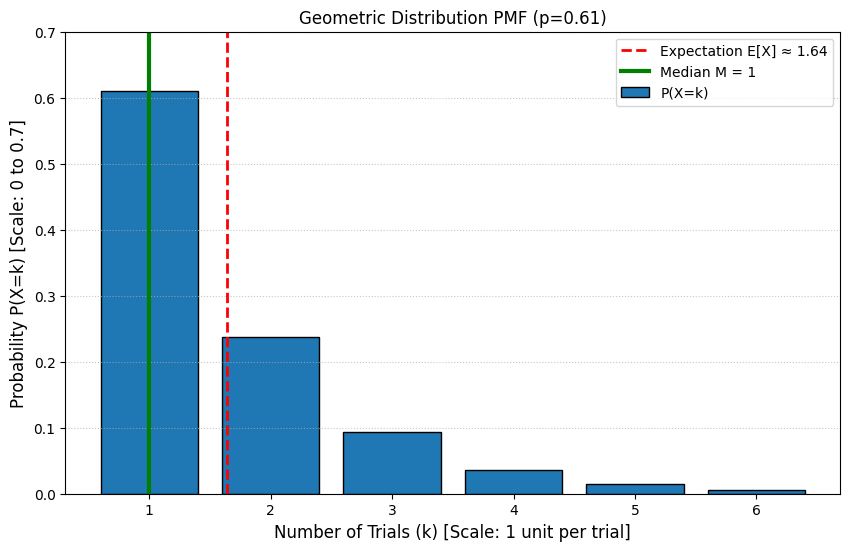

In [39]:
plt.figure(figsize=(10, 6))

# Plotting the PMF using a bar plot
plt.bar(k_values, probabilities, color='#1f77b4', edgecolor='black', label='P(X=k)')

# Mark Expectation
plt.axvline(E_X, color='red', linestyle='--', linewidth=2,
            label=f'Expectation E[X] ≈ {E_X:.2f}')

# Mark Median
plt.axvline(M, color='green', linestyle='-', linewidth=3,
            label=f'Median M = {M:.0f}')

# Formatting and Scale (required by assignment)
plt.title(f'Geometric Distribution PMF (p={prob_success})')
plt.xlabel('Number of Trials (k) [Scale: 1 unit per trial]', fontsize=12)
plt.ylabel('Probability P(X=k) [Scale: 0 to 0.7]', fontsize=12)
plt.xticks(k_values)
plt.ylim(0, 0.7) # Explicitly setting Y scale for clarity
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.show()



**Justification of Tool Usage:**

We utilize Python's standard statistical (scipy) and plotting (matplotlib) libraries.

These tools are widely accepted and trusted for producing accurate numerical results and visualizations in scientific computation.